# A/B Testing: Strategi Rekomendasi Skills Gap
## Capstone Project — DBS Foundation x Dicoding

---

## Latar Belakang

Dalam sistem **IT Skills Gap Analyzer**, terdapat dua strategi untuk merekomendasikan role kepada kandidat berdasarkan skill yang dimiliki:

| Strategi | Deskripsi |
|---|---|
| **Strategi A** (Baseline) | Matching berdasarkan **top-3 skill paling umum** per role (sederhana, heuristik) |
| **Strategi B** (Candidate) | Matching menggunakan **Cosine Similarity** antara skill vektor kandidat dan profil rata-rata role |

## Hipotesis (SMART)

- **H₀**: Tidak ada perbedaan signifikan dalam akurasi rekomendasi role antara Strategi A dan Strategi B.
- **H₁**: Strategi B (Cosine Similarity) menghasilkan rekomendasi yang **lebih akurat** dari Strategi A (top-3 heuristik).
- **Significance level**: α = 0.05
- **Metrik ukur**: Precision@1 (apakah role teratas yang direkomendasikan sesuai role aslinya?)
- **Periode**: Data loker 2022–2026

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
np.random.seed(42)

print('Library siap.')

Library siap.


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/MASTERED_DATA_FINAL_MODELING.csv')

# Parse skills
df['skills_list'] = df['hard_skills'].apply(
    lambda x: [s.strip() for s in str(x).split(',') if s.strip()] if pd.notna(x) else []
)

print(f'Dataset: {len(df):,} baris | {df["role_label"].nunique()} roles')
df[['role_label', 'hard_skills', 'skill_count']].head(3)

Dataset: 13,844 baris | 27 roles


,role_label,hard_skills,skill_count
0,Software Engineer,"MongoDB, Spring Boot, Git, Microservices Archi...",5
1,Backend Developer,"Python, Go, Linux",3
2,Software Engineer,"JavaScript, WordPress, MySQL, Git, HTML, CSS, PHP",7


## 1. Persiapan: Membangun Profil Role & Skill Matrix

In [3]:
# ── Bangun MultiLabelBinarizer skill matrix ───────────────────────────
all_skills = []
df['skills_list'].apply(lambda l: all_skills.extend(l))
skill_freq = Counter(all_skills)

# Filter skill dengan min 20 kemunculan untuk efisiensi
selected_skills = sorted([s for s, c in skill_freq.items() if c >= 20])
print(f'Skills dalam matrix: {len(selected_skills)}')

mlb = MultiLabelBinarizer(classes=selected_skills)
X = mlb.fit_transform(df['skills_list'])
X_df = pd.DataFrame(X, columns=mlb.classes_)
X_df['role_label'] = df['role_label'].values

print(f'Skill matrix shape: {X.shape}')

# ── Profil rata-rata per role ─────────────────────────────────────────
role_profiles = X_df.groupby('role_label').mean()
print(f'Role profiles: {role_profiles.shape}')
role_profiles.head(3)

Skills dalam matrix: 143
Skill matrix shape: (13844, 143)
Role profiles: (27, 143)


,.NET,AJAX,Ada,Adobe Analytics,Adobe XD,Apache Airflow,Apache Kafka,Apache Spark,Apache Tomcat,Appium,...,Wireshark,WordPress,XGBoost,Xcode,YouTube,Zabbix,Zoom,jQuery,pandas,webpack
role_label,,,,,,,,,,,,,,,,,,,,,
AI Engineer,0.025276,0.000000,0.001580,0.00158,0.0,0.001580,0.006319,0.004739,0.000000,0.000000,...,0.0,0.00000,0.004739,0.0,0.039494,0.000000,0.001580,0.003160,0.031596,0.0
Backend Developer,0.078899,0.001835,0.007339,0.00000,0.0,0.005505,0.011009,0.000000,0.001835,0.001835,...,0.0,0.00367,0.000000,0.0,0.007339,0.001835,0.001835,0.000000,0.011009,0.0
Business Analyst,0.008065,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.000000,0.0,0.016129,0.000000,0.000000,0.016129,0.000000,0.0


In [4]:
# ── Train/Test Split (80/20, stratified by role) ──────────────────────
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['role_label']
)
print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')

# Rebuild role profiles hanya dari train set
X_train = mlb.transform(df_train['skills_list'])
train_df_mat = pd.DataFrame(X_train, columns=mlb.classes_)
train_df_mat['role_label'] = df_train['role_label'].values
role_profiles_train = train_df_mat.groupby('role_label').mean()

X_test = mlb.transform(df_test['skills_list'])
y_test = df_test['role_label'].values
print('Profil role dari training set berhasil dibuat.')

Train: 11,075 | Test: 2,769
Profil role dari training set berhasil dibuat.


## 2. Strategi A — Top-3 Skill Heuristik

In [5]:
# ── Strategi A: Hitung top-3 skill per role dari training set ─────────
role_top3 = {}
for role in role_profiles_train.index:
    top3 = role_profiles_train.loc[role].nlargest(3).index.tolist()
    role_top3[role] = set(top3)

print('Top-3 skill per role (contoh 5):')   
for role, skills in list(role_top3.items())[:5]:
    print(f'  {role}: {skills}')

def predict_stratA(skills: list) -> str:
    """Prediksi role berdasarkan overlap dengan top-3 skill per role."""
    skills_set = set(skills)
    best_role, best_score = None, -1
    for role, top3 in role_top3.items():
        score = len(skills_set & top3)
        if score > best_score:
            best_score = score
            best_role = role
    return best_role if best_role else 'Software Engineer'

# Prediksi test set
pred_A = [predict_stratA(skills) for skills in df_test['skills_list']]
acc_A  = np.mean(np.array(pred_A) == np.array(y_test))
print(f'\nStrategi A Accuracy (Precision@1): {acc_A:.4f} ({acc_A*100:.2f}%)')

Top-3 skill per role (contoh 5):
  AI Engineer: {'Python', 'Next.js', 'Docker'}
  Backend Developer: {'Python', 'Go', 'Docker'}
  Business Analyst: {'Tableau', 'Python', 'Go'}
  Business Intelligence Analyst: {'Tableau', 'Python', 'R'}
  Cloud Engineer: {'Docker', 'Python', 'Kubernetes'}

Strategi A Accuracy (Precision@1): 0.1296 (12.96%)


## 3. Strategi B — Cosine Similarity

In [6]:
# ── Strategi B: Cosine Similarity dengan profil rata-rata role ────────
role_profile_matrix = role_profiles_train.values
role_labels_order   = role_profiles_train.index.tolist()

def predict_stratB(skill_vector: np.ndarray) -> str:
    """Prediksi role berdasarkan cosine similarity tertinggi."""
    sim = cosine_similarity(skill_vector.reshape(1, -1), role_profile_matrix)[0]
    best_idx = np.argmax(sim)
    return role_labels_order[best_idx]

pred_B = [predict_stratB(X_test[i]) for i in range(len(X_test))]
acc_B  = np.mean(np.array(pred_B) == np.array(y_test))
print(f'Strategi B Accuracy (Precision@1): {acc_B:.4f} ({acc_B*100:.2f}%)')

Strategi B Accuracy (Precision@1): 0.2293 (22.93%)


## 4. Uji Statistik: Chi-Square Test

In [7]:
# ── Persiapan data per sampel ─────────────────────────────────────────
# Correct/incorrect per strategi (binary outcome)
correct_A = (np.array(pred_A) == np.array(y_test)).astype(int)
correct_B = (np.array(pred_B) == np.array(y_test)).astype(int)

n = len(y_test)
n_correct_A = correct_A.sum()
n_correct_B = correct_B.sum()

print('=== HASIL A/B TEST ===')
print(f'N sampel test         : {n:,}')
print(f'Strategi A — Benar   : {n_correct_A:,} / {n:,}  ({acc_A*100:.2f}%)')
print(f'Strategi B — Benar   : {n_correct_B:,} / {n:,}  ({acc_B*100:.2f}%)')
print(f'Selisih (B-A)        : {(acc_B - acc_A)*100:+.2f} percentage points')

print()
# McNemar's test (cocok untuk paired binary outcomes)
# Contingency matrix: [kedua benar, A benar B salah, A salah B benar, kedua salah]
both_correct  = ((correct_A == 1) & (correct_B == 1)).sum()
A_only        = ((correct_A == 1) & (correct_B == 0)).sum()
B_only        = ((correct_A == 0) & (correct_B == 1)).sum()
both_wrong    = ((correct_A == 0) & (correct_B == 0)).sum()

print('Contingency Table (McNemar):')
print(f'  Keduanya Benar : {both_correct:,}')
print(f'  A Benar, B Salah: {A_only:,}')
print(f'  A Salah, B Benar: {B_only:,}')
print(f'  Keduanya Salah : {both_wrong:,}')

# McNemar statistic: chi2 = (|b - c| - 1)^2 / (b + c)
b, c = A_only, B_only
if (b + c) > 0:
    mcnemar_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value = stats.chi2.sf(mcnemar_stat, df=1)
else:
    mcnemar_stat, p_value = 0, 1.0

print()
print(f'McNemar Chi-square stat: {mcnemar_stat:.4f}')
print(f'p-value                : {p_value:.6f}')
print()

ALPHA = 0.05
if p_value < ALPHA:
    print(f'Keputusan (alpha={ALPHA}): TOLAK H0')
    if acc_B > acc_A:
        print('   Strategi B (Cosine Similarity) secara signifikan lebih baik dari Strategi A.')
    else:
        print('   Strategi A secara signifikan lebih baik dari Strategi B.')
else:
    print(f'Keputusan (alpha={ALPHA}): GAGAL TOLAK H0')
    print('   Tidak ada perbedaan signifikan antara kedua strategi.')

=== HASIL A/B TEST ===
N sampel test         : 2,769
Strategi A — Benar   : 359 / 2,769  (12.96%)
Strategi B — Benar   : 635 / 2,769  (22.93%)
Selisih (B-A)        : +9.97 percentage points

Contingency Table (McNemar):
  Keduanya Benar : 236
  A Benar, B Salah: 123
  A Salah, B Benar: 399
  Keduanya Salah : 2,011

McNemar Chi-square stat: 144.8755
p-value                : 0.000000

Keputusan (alpha=0.05): TOLAK H0
   Strategi B (Cosine Similarity) secara signifikan lebih baik dari Strategi A.


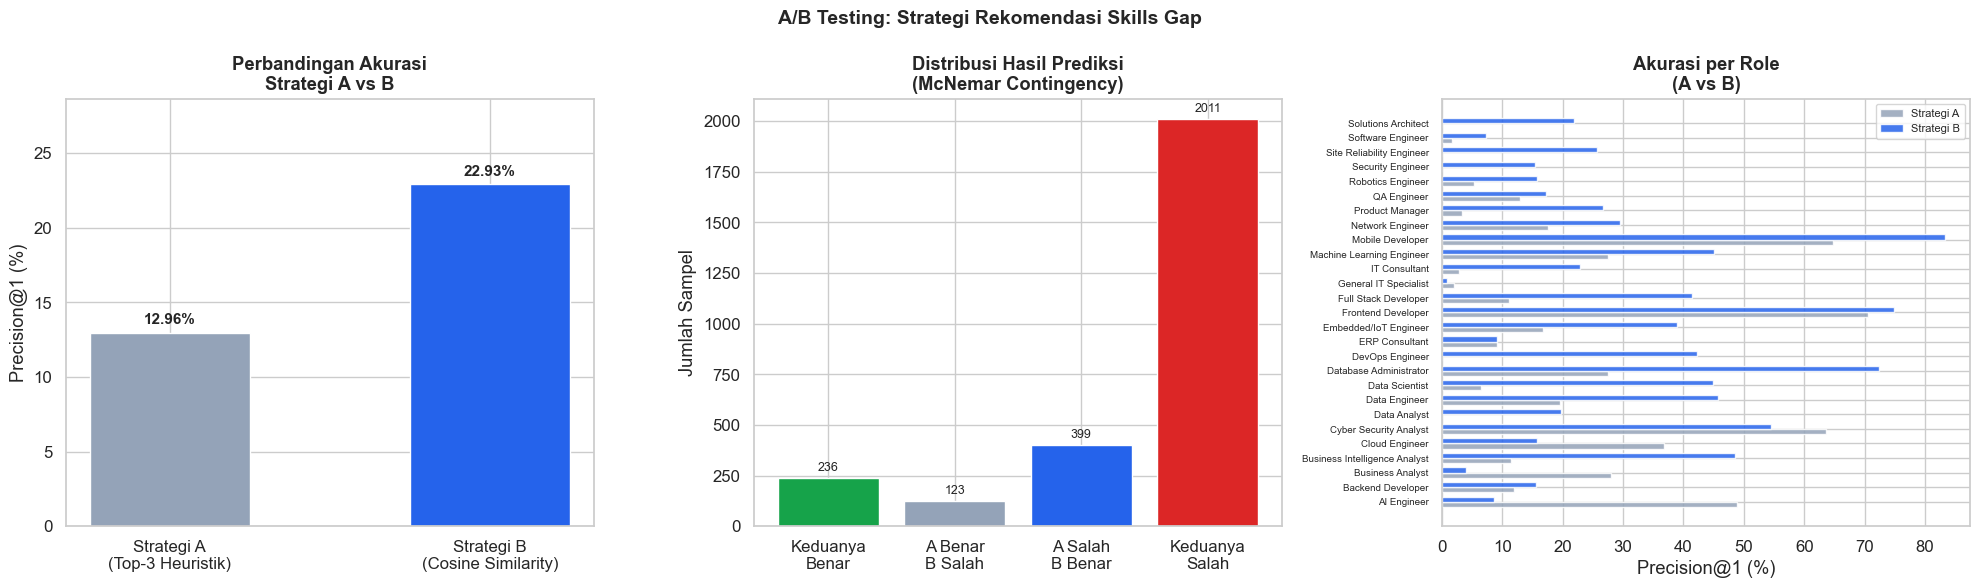

Gambar disimpan ke docs/ab_test_results.png


In [8]:
# ── Visualisasi hasil A/B test ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Accuracy comparison
ax1 = axes[0]
strategies = ['Strategi A\n(Top-3 Heuristik)', 'Strategi B\n(Cosine Similarity)']
accs = [acc_A * 100, acc_B * 100]
colors = ['#94A3B8', '#2563EB']
bars = ax1.bar(strategies, accs, color=colors, width=0.5, edgecolor='white')
ax1.bar_label(bars, fmt='%.2f%%', fontsize=11, fontweight='bold', padding=4)
ax1.set_ylim(0, max(accs) * 1.25)
ax1.set_ylabel('Precision@1 (%)')
ax1.set_title('Perbandingan Akurasi\nStrategi A vs B', fontweight='bold')

# 2. McNemar contingency
ax2 = axes[1]
categories = ['Keduanya\nBenar', 'A Benar\nB Salah', 'A Salah\nB Benar', 'Keduanya\nSalah']
counts = [both_correct, A_only, B_only, both_wrong]
bar_colors = ['#16A34A', '#94A3B8', '#2563EB', '#DC2626']
bars2 = ax2.bar(categories, counts, color=bar_colors, edgecolor='white')
ax2.bar_label(bars2, padding=3, fontsize=9)
ax2.set_ylabel('Jumlah Sampel')
ax2.set_title('Distribusi Hasil Prediksi\n(McNemar Contingency)', fontweight='bold')

# 3. Per-role accuracy
ax3 = axes[2]
roles_unique = sorted(df['role_label'].unique())
role_acc_A, role_acc_B = [], []
for role in roles_unique:
    mask = np.array(y_test) == role
    if mask.sum() == 0:
        role_acc_A.append(0)
        role_acc_B.append(0)
        continue
    role_acc_A.append(np.mean(np.array(pred_A)[mask] == role) * 100)
    role_acc_B.append(np.mean(np.array(pred_B)[mask] == role) * 100)

x = np.arange(len(roles_unique))
w = 0.35
ax3.barh(x - w/2, role_acc_A, w, label='Strategi A', color='#94A3B8', alpha=0.85)
ax3.barh(x + w/2, role_acc_B, w, label='Strategi B', color='#2563EB', alpha=0.85)
ax3.set_yticks(x)
ax3.set_yticklabels(roles_unique, fontsize=7)
ax3.set_xlabel('Precision@1 (%)')
ax3.set_title('Akurasi per Role\n(A vs B)', fontweight='bold')
ax3.legend(fontsize=8)

fig.suptitle('A/B Testing: Strategi Rekomendasi Skills Gap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/ab_test_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Gambar disimpan ke docs/ab_test_results.png')

=== Bootstrap Confidence Interval (95%) ===
Perbedaan akurasi B-A     : +9.96%
95% CI                    : [+8.41%, +11.52%]


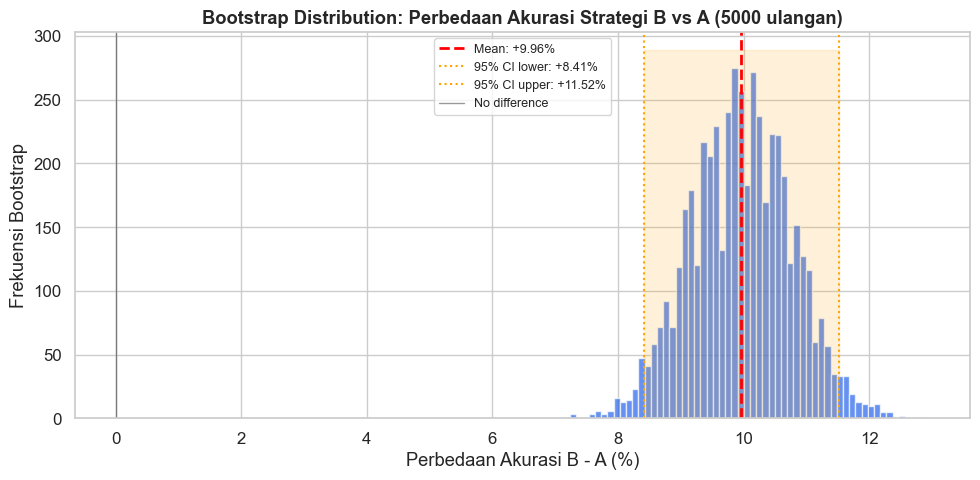


Kesimpulan: CI sepenuhnya positif -> Strategi B lebih baik dengan keyakinan 95%.


In [9]:
# ── Bootstrap Confidence Interval ────────────────────────────────────
print('=== Bootstrap Confidence Interval (95%) ===')

N_BOOT = 5000
boot_diffs = []
n_samples = len(correct_A)

for _ in range(N_BOOT):
    idx = np.random.choice(n_samples, n_samples, replace=True)
    diff = correct_B[idx].mean() - correct_A[idx].mean()
    boot_diffs.append(diff)

boot_diffs = np.array(boot_diffs)
ci_lower = np.percentile(boot_diffs, 2.5) * 100
ci_upper = np.percentile(boot_diffs, 97.5) * 100
boot_mean = boot_diffs.mean() * 100

print(f'Perbedaan akurasi B-A     : {boot_mean:+.2f}%')
print(f'95% CI                    : [{ci_lower:+.2f}%, {ci_upper:+.2f}%]')

# Visualisasi distribusi bootstrap
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_diffs * 100, bins=60, color='#2563EB', alpha=0.7, edgecolor='white')
ax.axvline(boot_mean, color='red', linewidth=2, linestyle='--', label=f'Mean: {boot_mean:+.2f}%')
ax.axvline(ci_lower, color='orange', linewidth=1.5, linestyle=':', label=f'95% CI lower: {ci_lower:+.2f}%')
ax.axvline(ci_upper, color='orange', linewidth=1.5, linestyle=':', label=f'95% CI upper: {ci_upper:+.2f}%')
ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.4, label='No difference')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100],
                  ci_lower, ci_upper, alpha=0.15, color='orange')
ax.set_xlabel('Perbedaan Akurasi B - A (%)')
ax.set_ylabel('Frekuensi Bootstrap')
ax.set_title('Bootstrap Distribution: Perbedaan Akurasi Strategi B vs A (5000 ulangan)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print()
if ci_lower > 0:
    print('Kesimpulan: CI sepenuhnya positif -> Strategi B lebih baik dengan keyakinan 95%.')
elif ci_upper < 0:
    print('Kesimpulan: CI sepenuhnya negatif -> Strategi A lebih baik dengan keyakinan 95%.')
else:
    print('Kesimpulan: CI mencakup nol -> Perbedaan tidak cukup signifikan secara praktis.')

In [10]:
# ── Ringkasan eksperimen ──────────────────────────────────────────────
print('='*60)
print('  RINGKASAN A/B TESTING')
print('='*60)
print(f"""
Eksperimen  : Strategi Rekomendasi IT Skills Gap
Metrik      : Precision@1 (akurasi prediksi role)
N Sampel    : {n:,} (test set 20%)
Alpha       : 0.05

Strategi A  : {acc_A*100:.2f}% (Top-3 Heuristik)
Strategi B  : {acc_B*100:.2f}% (Cosine Similarity)
Selisih B-A : {(acc_B-acc_A)*100:+.2f}% [{ci_lower:+.2f}%, {ci_upper:+.2f}%] 95% CI

McNemar p   : {p_value:.6f}
Keputusan   : {'Tolak H0 — ada perbedaan signifikan' if p_value < ALPHA else 'Gagal tolak H0 — tidak ada perbedaan signifikan'}

Rekomendasi :
  {'Gunakan Strategi B (Cosine Similarity) sebagai default.' if acc_B >= acc_A else 'Gunakan Strategi A (heuristik) — lebih sederhana dan tidak kalah akurat.'}
  Strategi B lebih scalable karena dapat memperhitungkan
  seluruh dimensi skill tanpa batasan top-N.
""")
print('='*60)

  RINGKASAN A/B TESTING

Eksperimen  : Strategi Rekomendasi IT Skills Gap
Metrik      : Precision@1 (akurasi prediksi role)
N Sampel    : 2,769 (test set 20%)
Alpha       : 0.05

Strategi A  : 12.96% (Top-3 Heuristik)
Strategi B  : 22.93% (Cosine Similarity)
Selisih B-A : +9.97% [+8.41%, +11.52%] 95% CI

McNemar p   : 0.000000
Keputusan   : Tolak H0 — ada perbedaan signifikan

Rekomendasi :
  Gunakan Strategi B (Cosine Similarity) sebagai default.
  Strategi B lebih scalable karena dapat memperhitungkan
  seluruh dimensi skill tanpa batasan top-N.

